In [4]:
import json
from decimal import Decimal
import pandas as pd
import matplotlib.pyplot as plt

# US915 as JSON
freqs = [Decimal('902.3') + Decimal('0.2') * i for i in range(int((Decimal('914.9') - Decimal('902.3')) / Decimal('0.2')) + 1)]
freqs_json = json.dumps([str(d) for d in freqs])
freqs_json




'["902.3", "902.5", "902.7", "902.9", "903.1", "903.3", "903.5", "903.7", "903.9", "904.1", "904.3", "904.5", "904.7", "904.9", "905.1", "905.3", "905.5", "905.7", "905.9", "906.1", "906.3", "906.5", "906.7", "906.9", "907.1", "907.3", "907.5", "907.7", "907.9", "908.1", "908.3", "908.5", "908.7", "908.9", "909.1", "909.3", "909.5", "909.7", "909.9", "910.1", "910.3", "910.5", "910.7", "910.9", "911.1", "911.3", "911.5", "911.7", "911.9", "912.1", "912.3", "912.5", "912.7", "912.9", "913.1", "913.3", "913.5", "913.7", "913.9", "914.1", "914.3", "914.5", "914.7", "914.9"]'

In [5]:
freqs = [Decimal('902.3') + Decimal('0.2') * i for i in range(int((Decimal('914.9') - Decimal('902.3')) / Decimal('0.2')) + 1)]
freqs_csv = ','.join([str(f) for f in freqs])
freqs_csv

'902.3,902.5,902.7,902.9,903.1,903.3,903.5,903.7,903.9,904.1,904.3,904.5,904.7,904.9,905.1,905.3,905.5,905.7,905.9,906.1,906.3,906.5,906.7,906.9,907.1,907.3,907.5,907.7,907.9,908.1,908.3,908.5,908.7,908.9,909.1,909.3,909.5,909.7,909.9,910.1,910.3,910.5,910.7,910.9,911.1,911.3,911.5,911.7,911.9,912.1,912.3,912.5,912.7,912.9,913.1,913.3,913.5,913.7,913.9,914.1,914.3,914.5,914.7,914.9'

In [7]:
# LA915
la_freqs = [Decimal('915.2') + Decimal('0.2') * i for i in range(int((Decimal('916.6') - Decimal('915.2')) / Decimal('0.2')) + 1)]
la_freqs_csv = ','.join([str(f) for f in la_freqs])
la_freqs_csv


'915.2,915.4,915.6,915.8,916.0,916.2,916.4,916.6'

# using the django shell
from device.models import ChannelPlan
ChannelPlan.objects.create(name='US915', freqs=freqs_csv)
ChannelPlan.objects.create(name='LA915', freqs=la_freqs_csv)

In [42]:
# Counting Channel Plan Hits and Misses

# load sample data
device_freqs_df = pd.DataFrame({
    'freq': ['915.8', '915.4', '910.6', '916.0', '916.2', '916.4', '915.2', '916.6'],
    'count': [13,12,11,9,8,7,5,4]
})
device_freqs_df['freq'] = device_freqs_df['freq'].astype('category')
print(device_freqs_df.info())
print(device_freqs_df)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   freq    8 non-null      category
 1   count   8 non-null      int64   
dtypes: category(1), int64(1)
memory usage: 564.0 bytes
None
    freq  count
0  915.8     13
1  915.4     12
2  910.6     11
3  916.0      9
4  916.2      8
5  916.4      7
6  915.2      5
7  916.6      4


In [43]:

# set the channel plan
cp_freqs = ['915.2', '915.4', '915.6', '915.8', '916.0', '916.2', '916.4', '916.6']
print(type(cp_freqs))
print(cp_freqs)

<class 'list'>
['915.2', '915.4', '915.6', '915.8', '916.0', '916.2', '916.4', '916.6']


In [60]:
device_freqs_in_df = device_freqs_df[device_freqs_df['freq'].isin(cp_freqs)]
device_freqs_out_df = device_freqs_df[~device_freqs_df['freq'].isin(cp_freqs)]
print(device_freqs_in_df.info())
print(device_freqs_out_df)

<class 'pandas.core.frame.DataFrame'>
Index: 7 entries, 0 to 7
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   freq    7 non-null      category
 1   count   7 non-null      int64   
dtypes: category(1), int64(1)
memory usage: 483.0 bytes
None
    freq  count
2  910.6     11


In [62]:
# Create a dataframe from the list
cp_freqs_df = pd.DataFrame(cp_freqs, columns=['freq'])
device_freqs_in_df = cp_freqs_df.merge(device_freqs_in_df, on='freq', how='outer').fillna(0)
device_freqs_in_df['count'] = device_freqs_in_df['count'].astype(int)

print(device_freqs_in_df.info())
print(device_freqs_in_df)
print(device_freqs_out_df.info())
print(device_freqs_out_df)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   freq    8 non-null      object
 1   count   8 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 256.0+ bytes
None
    freq  count
0  915.2      5
1  915.4     12
2  915.6      0
3  915.8     13
4  916.0      9
5  916.2      8
6  916.4      7
7  916.6      4
<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 2 to 2
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   freq    1 non-null      category
 1   count   1 non-null      int64   
dtypes: category(1), int64(1)
memory usage: 381.0 bytes
None
    freq  count
2  910.6     11


In [64]:
device_freqs_in_df_pivot = device_freqs_in_df.pivot(columns='freq', values='count')
device_freqs_in_df_pivot

freq,915.2,915.4,915.6,915.8,916.0,916.2,916.4,916.6
0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,12.0,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,13.0,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,9.0,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0


In [83]:
df_in = device_freqs_in_df.set_index('freq').T

print(df_in.info())
print(df_in)




<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, count to count
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   915.2   1 non-null      int64
 1   915.4   1 non-null      int64
 2   915.6   1 non-null      int64
 3   915.8   1 non-null      int64
 4   916.0   1 non-null      int64
 5   916.2   1 non-null      int64
 6   916.4   1 non-null      int64
 7   916.6   1 non-null      int64
dtypes: int64(8)
memory usage: 72.0+ bytes
None
freq   915.2  915.4  915.6  915.8  916.0  916.2  916.4  916.6
count      5     12      0     13      9      8      7      4


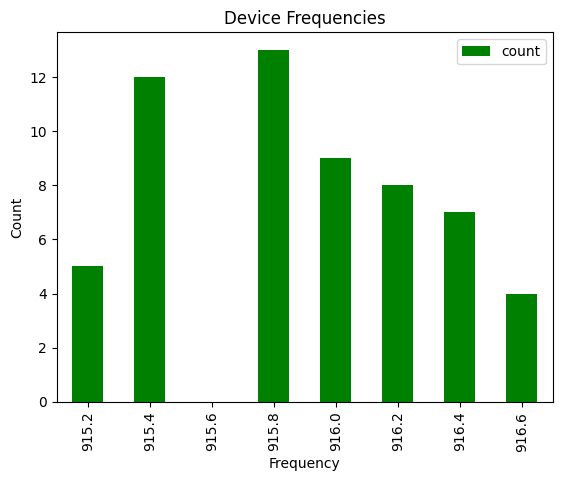

In [85]:


device_freqs_in_df.plot(x='freq', y='count', kind='bar', color='green')
plt.xlabel('Frequency')
plt.ylabel('Count')
plt.title('Device Frequencies')


plt.show()



In [97]:
device_freqs_out_df

if device_freqs_out_df.empty:
    # Perform actions if the dataframe is empty
    print("The dataframe is empty.")
else:
    # Perform actions if the dataframe is not empty
    print("The dataframe is not empty.")
    print(device_freqs_out_df)

The dataframe is not empty.
    freq  count
2  910.6     11


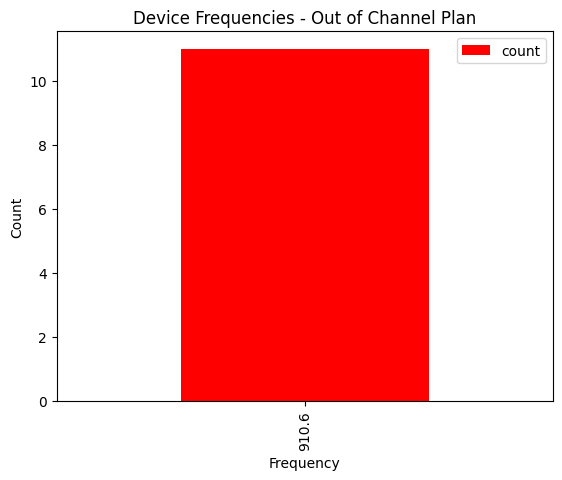

In [99]:
device_freqs_out_df.plot(x='freq', y='count', kind='bar', color='red')
plt.xlabel('Frequency')
plt.ylabel('Count')
plt.title('Device Frequencies - Out of Channel Plan')


plt.show()